In [43]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

folder_path = "case_data"   # change if needed

all_cases = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".npz"):
        file_path = os.path.join(folder_path, filename)

        # load file
        data = np.load(file_path)

        # store using filename (without .npz) as key
        case_name = filename.replace(".npz", "")
        all_cases[case_name] = data

print("Loaded files:")
print(list(all_cases.keys()))

Loaded files:
['00_BASE', '11_G_PM', '12_G_SPH', '21_D_ON', '22_D_OFF', '23_D_CD110', '24_D_CD150', '25_D_CD200', '31_TBP_ALL', '32_TBP_NONE', '33_TBP_M', '33_TBP_MS', '41_SRP_ON', '42_SRP_OFF', '43_SRP110', '44_SRP150', '45_SRP200']


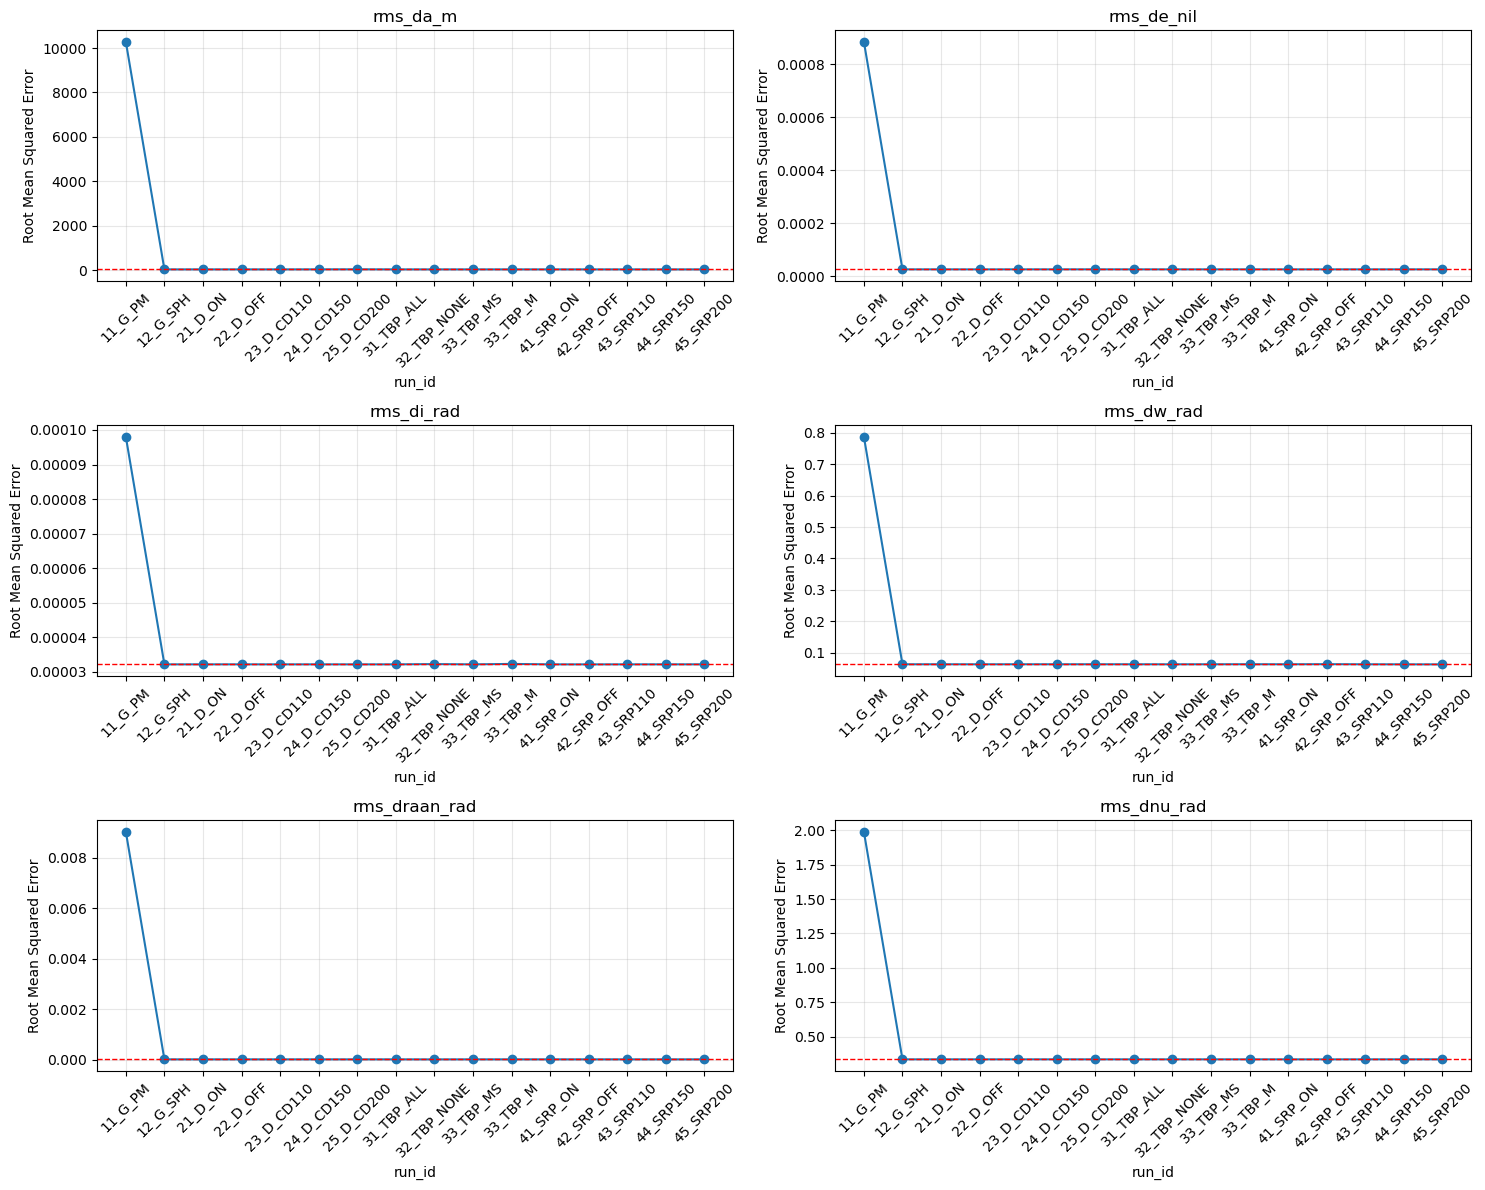

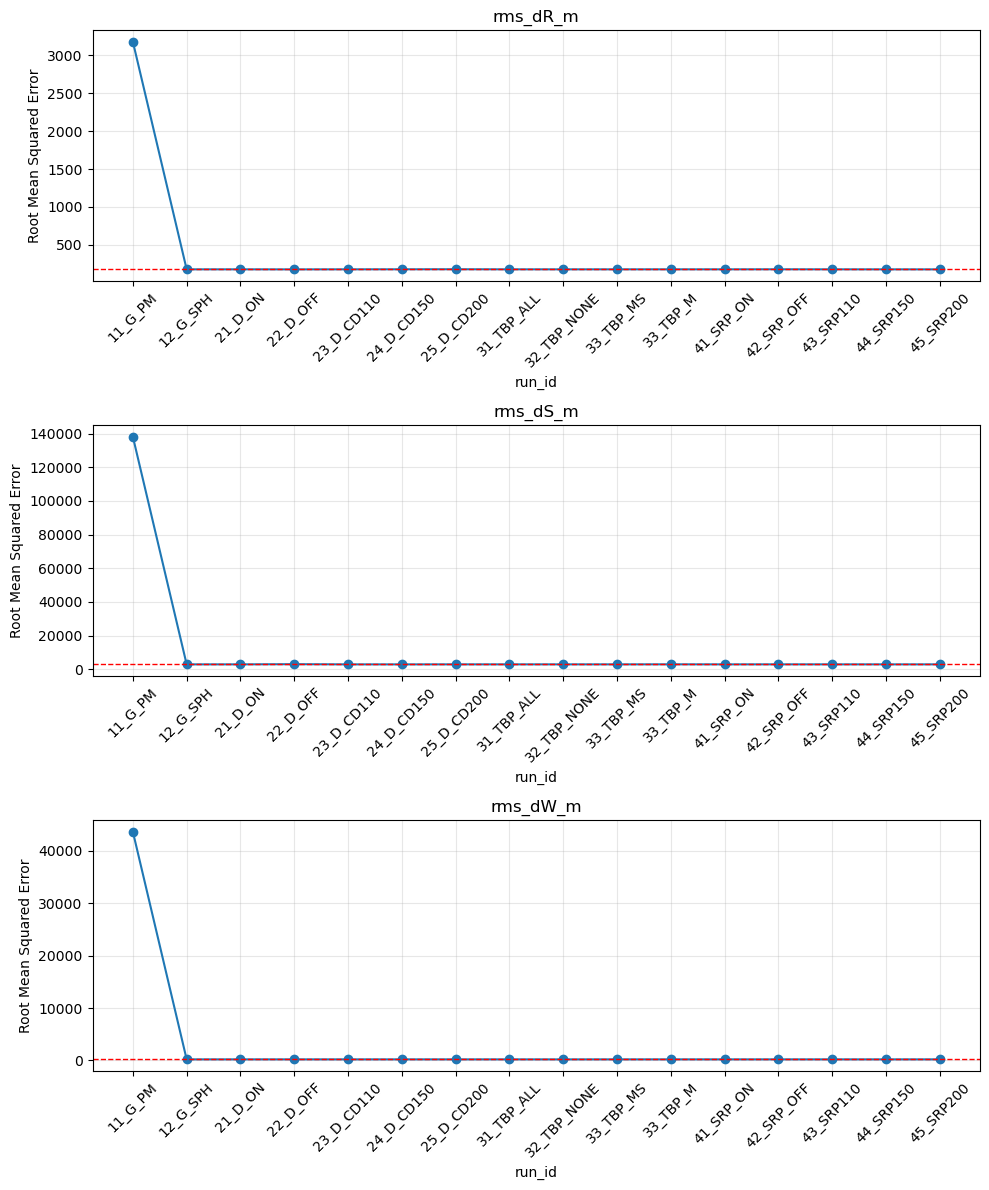

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load sensitivity table
SEN = pd.read_csv("results/sensitivity_table.csv")

KEP_COLS = ["rms_da_m", "rms_de_nil", "rms_di_rad", "rms_dw_rad", "rms_draan_rad", "rms_dnu_rad"]

RSW_POS_COLS = ["rms_dR_m", "rms_dS_m", "rms_dW_m"]

SEN_plot = SEN[SEN["run_id"] != "00_BASE"]
x = SEN_plot["run_id"].astype(str)


# ---------- Plot Keplerian RMS (2x3) ----------
fig, ax = plt.subplots(3, 2, figsize=(15, 12))
ax = ax.ravel()

for i, col in enumerate(KEP_COLS):
    ax[i].plot(x, SEN_plot[col].values, marker="o")
    baseline_value = SEN.loc[SEN["run_id"] == "00_BASE", col].values[0]
    ax[i].axhline(baseline_value, linestyle="--", linewidth=1, color = 'red')
    ax[i].set_title(col)
    ax[i].grid(True, alpha=0.3)
    ax[i].tick_params(axis="x", rotation=45)
    ax[i].set_xlabel("run_id")
    ax[i].set_ylabel(f"Root Mean Squared Error")

plt.tight_layout()
plt.savefig("results/rms_keplerian_grid.png", dpi=200)
plt.show()

# ---------- Plot RSW RMS (3x1) ----------
fig, ax = plt.subplots(3, 1, figsize=(10, 12))
ax = ax.ravel()

for i, col in enumerate(RSW_POS_COLS):
    ax[i].plot(x, SEN_plot[col].values, marker="o")
    baseline_value = SEN.loc[SEN["run_id"] == "00_BASE", col].values[0]
    ax[i].axhline(baseline_value, linestyle="--", linewidth=1, color = 'red')
    ax[i].set_title(col)
    ax[i].grid(True, alpha=0.3)
    ax[i].tick_params(axis="x", rotation=45)
    ax[i].set_xlabel("run_id")
    ax[i].set_ylabel(f"Root Mean Squared Error")


plt.tight_layout()
plt.savefig("results/rms_rsw_grid.png", dpi=200)
plt.show()

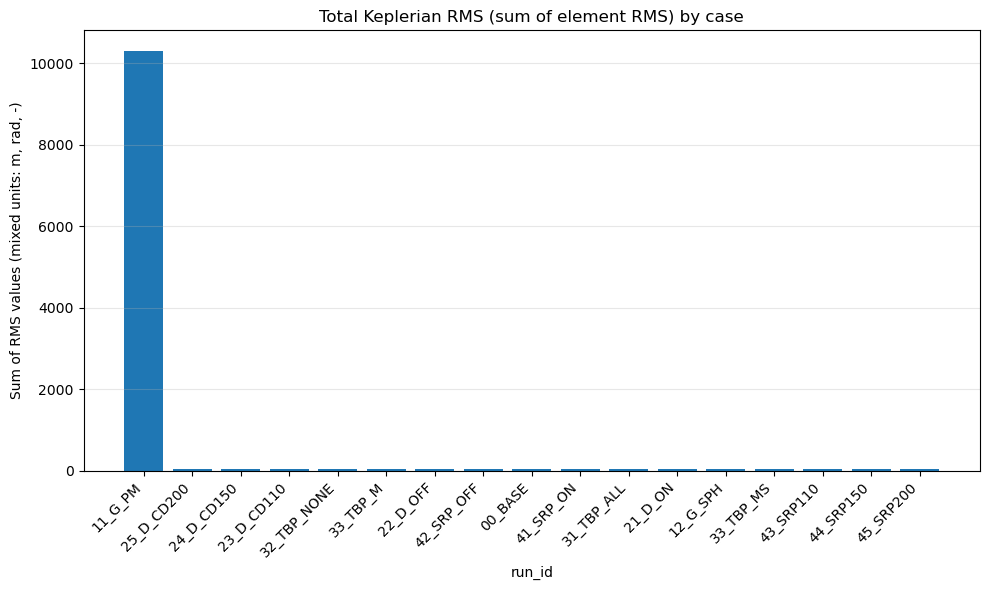

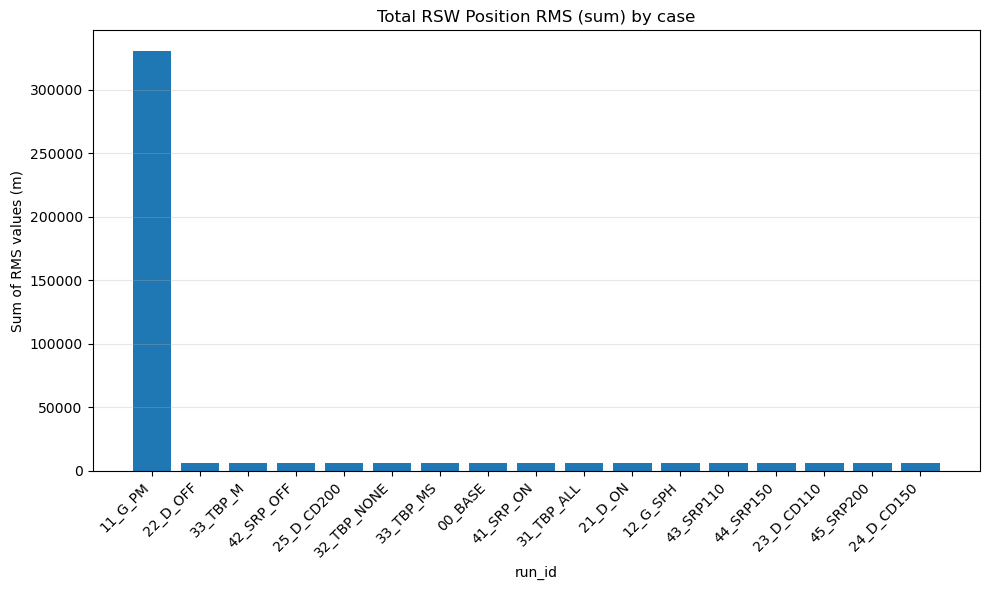

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

SEN = pd.read_csv("results/sensitivity_table.csv")

# --- Pick RMS columns ---
KEP_COLS = ["rms_da_m", "rms_de_nil", "rms_di_rad", "rms_dw_rad", "rms_draan_rad", "rms_dnu_rad"]

# Position-only RSW (meters)
RSW_POS_COLS = ["rms_dR_m", "rms_dS_m", "rms_dW_m", "rms_RSW_pos_m"]

# Velocity-only RSW (m/s)
RSW_VEL_COLS = ["rms_dVR_ms", "rms_dVS_ms", "rms_dVW_ms", "rms_RSW_vel_ms"]

# If you want ONE combined RSW score, you can combine pos+vel too (note: mixed units!)
# RSW_ALL_COLS = RSW_POS_COLS + RSW_VEL_COLS

# --- Build total scores ---
SEN["kep_rms_sum"] = SEN[KEP_COLS].sum(axis=1)

SEN["rsw_pos_rms_sum"] = SEN[RSW_POS_COLS].sum(axis=1)


# Optional: drop a case
# SEN = SEN[SEN["run_id"] != "11_G_PM"].reset_index(drop=True)

# --- Sort by highest impact (descending) ---
SEN_kep = SEN.sort_values("kep_rms_sum", ascending=False)
SEN_rsw_pos = SEN.sort_values("rsw_pos_rms_sum", ascending=False)


# --- Plot ordered bar charts (ranked “histograms”) ---
def plot_ranked_bar(df, score_col, title, ylabel, outpath):
    plt.figure(figsize=(10, 6))
    plt.bar(df["run_id"].astype(str), df[score_col].values)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("run_id")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()

plot_ranked_bar(SEN_kep, "kep_rms_sum",
                "Total Keplerian RMS (sum of element RMS) by case",
                "Sum of RMS values (mixed units: m, rad, -)",
                "results/ranked_kep_rms_sum.png")

plot_ranked_bar(SEN_rsw_pos, "rsw_pos_rms_sum",
                "Total RSW Position RMS (sum) by case",
                "Sum of RMS values (m)",
                "results/ranked_rsw_pos_rms_sum.png")



# --- (Optional) Save the ranking table ---
SEN[["run_id", "kep_rms_sum", "rsw_pos_rms_sum"]]\
    .sort_values("kep_rms_sum", ascending=False)\
    .to_csv("results/rms_sum_rankings.csv", index=False)

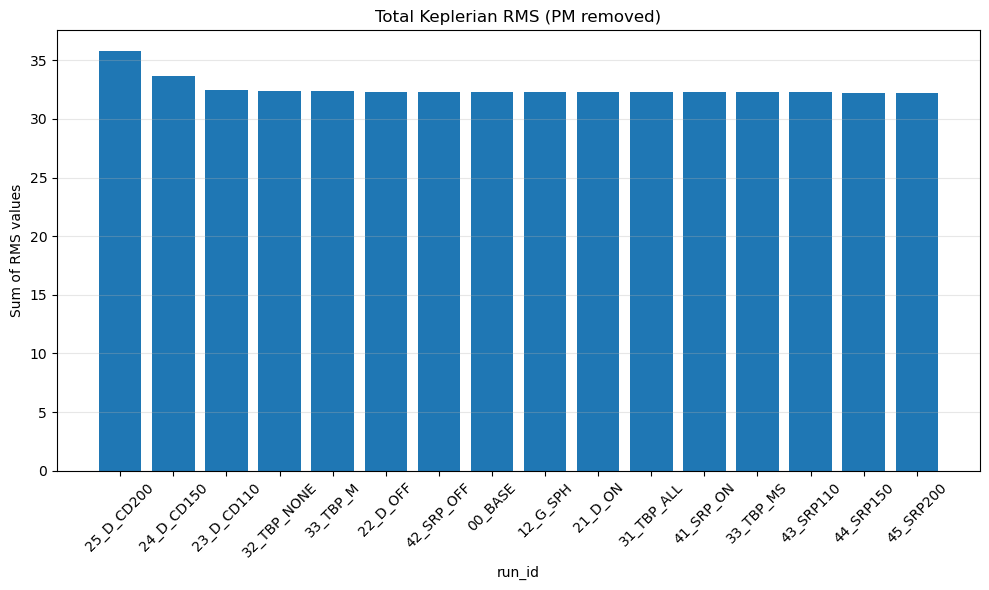

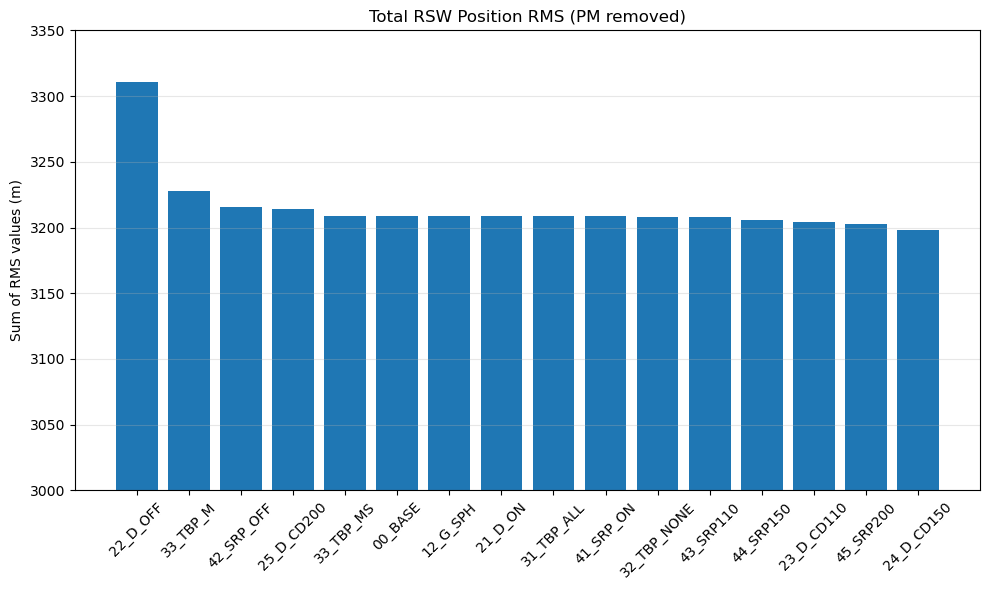

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
SEN = pd.read_csv("results/sensitivity_table.csv")

# ---- REMOVE PM ----
SEN = SEN[SEN["run_id"] != "11_G_PM"].reset_index(drop=True)

# ---- Define columns ----
KEP_COLS = [
    "rms_da_m", "rms_de_nil", "rms_di_rad",
    "rms_dw_rad", "rms_draan_rad", "rms_dnu_rad"
]

RSW_POS_COLS = [
    "rms_dR_m", "rms_dS_m", "rms_dW_m"
]

# ---- Create summed scores ----
SEN["kep_rms_sum"] = SEN[KEP_COLS].sum(axis=1)
SEN["rsw_rms_sum"] = SEN[RSW_POS_COLS].sum(axis=1)

# ---- Sort by highest impact ----
SEN_kep_sorted = SEN.sort_values("kep_rms_sum", ascending=False)
SEN_rsw_sorted = SEN.sort_values("rsw_rms_sum", ascending=False)

# ---- Plot Keplerian Ranking ----
plt.figure(figsize=(10,6))
plt.bar(SEN_kep_sorted["run_id"], SEN_kep_sorted["kep_rms_sum"])
plt.title("Total Keplerian RMS (PM removed)")
plt.ylabel("Sum of RMS values")
plt.xticks(rotation=45)
plt.xlabel("run_id")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot RSW Ranking ----
plt.figure(figsize=(10,6))
plt.bar(SEN_rsw_sorted["run_id"], SEN_rsw_sorted["rsw_rms_sum"])
plt.title("Total RSW Position RMS (PM removed)")
plt.ylabel("Sum of RMS values (m)")
plt.ylim(3000,3350)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()